# Part B: The Crucible - The Engine's Trial by Fire
* **Objective:**

    >To take our "perfect" engine and see how it performs on a messy, realistic problem, forcing us to debug and adapt.

* **Crucible Dataset:** 

    >We will simulate the famous Clothing1M dataset's primary challenge: noisy labels. We will use the CIFAR-10 dataset (a slightly more complex image dataset) and manually flip 40% of the training labels to be incorrect. Our pristine script, designed for clean data, will now face chaos.

In [12]:
# OLD code from before
# But with early stopping
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time

# Creating an Earlystoping class
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        """
        Args:
            patience (int) : How many epochs to wait adter last improvement before stopping.
            min_delta (float) : Minimum change to qualify as an improvement.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0.0
        self.best_loss = np.inf
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0 # Reset patience counter

        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True   


# 1.  Configuration
# for reproducibility
torch.manual_seed(42)

# Hyperparameters
LEARNING_RATE  = 0.001
BATCH_SIZE = 64
EPOCHS = 15

# Set device
device = "cuda" if torch.cuda.is_available() else 'cpu'
print(f"Using the device : {device}")

# 2. Loading the FashionMNIST dataset
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5),(0.5))
    ]
)

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True,
                                      transform=transform)

test_dataset =  datasets.FashionMNIST(root='./data',
                                      train=False,
                                      download=True,
                                      transform=transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
    )

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Define the model
class FashionMNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

model = FashionMNIST().to(device)

# 4. Loss and Optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = LEARNING_RATE)

# 5. The Training and Validation Functions

def train_one_epoch(loader, model, loss_fn, optimizer):
    model.train() # Set model for training mode
    running_loss = 0.0
    for batch, (X, y) in enumerate(loader):
        X, y = X.to(device), y.to(device)
        
        # 1. Forward pass
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    
    return running_loss / len(loader)


def validate_one_epoch(loader, model, loss_fn):
    model.eval() # set model to evaluation mode
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            pred = model(X)

            running_loss += loss_fn(pred, y).item()


            # calculate accuracy
            total += y.size(0)
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    avg_loss = running_loss / len(loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

early_stopping = EarlyStopping(patience=3, min_delta=0.001)
# --- 6. The Main Training Loop ---
print("Starting training...")
start_time = time.time()

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(train_loader, model, loss_fn, optimizer)
    val_loss, val_acc = validate_one_epoch(test_loader, model, loss_fn)
    early_stopping(val_loss)
    if early_stopping.early_stop:
        break
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

end_time = time.time()
print(f"Finished training in {end_time - start_time:.2f} seconds.")



Using the device : cuda
Starting training...
Epoch 1/15 | Train Loss: 0.5123 | Val Loss: 0.4196 | Val Acc: 84.53%
Epoch 2/15 | Train Loss: 0.3784 | Val Loss: 0.3967 | Val Acc: 85.44%
Epoch 3/15 | Train Loss: 0.3406 | Val Loss: 0.4100 | Val Acc: 85.44%
Epoch 4/15 | Train Loss: 0.3177 | Val Loss: 0.3583 | Val Acc: 86.93%
Epoch 5/15 | Train Loss: 0.2983 | Val Loss: 0.3326 | Val Acc: 88.29%
Epoch 6/15 | Train Loss: 0.2821 | Val Loss: 0.3358 | Val Acc: 88.20%
Epoch 7/15 | Train Loss: 0.2711 | Val Loss: 0.3346 | Val Acc: 88.03%
Finished training in 237.18 seconds.


### The crucible part

In [20]:
print("Starting Crucible: Testing with Noisy labels")


cifar_train = datasets.CIFAR10(root='./data', train=True, download=True,
                                      transform=transform)


# Function to introduce Noise in labels

def add_label_noise(dataset, noise_rate=0.4):
    print(f"Corrupting {noise_rate*100}% of labels...")
    num_samples = len(dataset)
    num_noisy = int(num_samples * noise_rate)
    noisy_indices = torch.randperm(num_samples)[:num_noisy]

    original_labels = torch.tensor(dataset.targets)
    noisy_labels = original_labels.clone()

    for i in noisy_indices:
        original_label = noisy_labels[i].item()
        # Flip to a new, incorrect random label
        possible_labels = [l for l in range(10) if l != original_label]
        noisy_labels[i] = torch.tensor(possible_labels[torch.randint(0, len(possible_labels), (1,)).item()])

    dataset.targets = noisy_labels.tolist()
        
    # Verify noise
    correct_labels = (original_labels == noisy_labels).sum().item()
    print(f"Accuracy of labels after corruption: {100 * correct_labels / num_samples:.2f}%")

    return dataset
    



##### Create the noisy dataset and a new loader
noisy_train_dataset = add_label_noise(cifar_train, noise_rate = 0.4)
noisy_train_loader  =  DataLoader(noisy_train_dataset, batch_size=BATCH_SIZE, shuffle = True)

cifar_test = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

noisy_test_loader = DataLoader(cifar_test, batch_size=BATCH_SIZE, shuffle=False)



#################################
# Reinitilize the model for a fair comparison (it needs different input size for Cifar)

class CifarClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        # CIFAR images are 3x32x32, not 1x28x28
        # Below is a very simple CNN
        self.net =  nn.Sequential(
            nn.Conv2d(3, 16,
                      kernel_size = 3,
                      padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),


            nn.Conv2d(16, 32,
                      kernel_size=3,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),


            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10)          
        )
    def forward(self, x):
        return self.net(x)
    
noisy_model = CifarClassifier().to(device)
noisy_optimizer = optim.Adam(noisy_model.parameters(), lr=LEARNING_RATE)

#  NOW, Let's train the model on the noisy dataset

for epoch in range(EPOCHS):
    train_loss =train_one_epoch(noisy_train_loader, 
                                noisy_model, 
                                loss_fn=loss_fn,
                                optimizer=noisy_optimizer)
    val_loss, val_acc = validate_one_epoch(noisy_test_loader,
                                           noisy_model,
                                           loss_fn=loss_fn)
    print(f"[Noisy] Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

Starting Crucible: Testing with Noisy labels
Files already downloaded and verified
Corrupting 40.0% of labels...
Accuracy of labels after corruption: 60.00%
Files already downloaded and verified
[Noisy] Epoch 1/15 | Train Loss: 2.0975 | Val Loss: 1.5726 | Val Acc: 51.30%
[Noisy] Epoch 2/15 | Train Loss: 1.9836 | Val Loss: 1.4500 | Val Acc: 58.56%
[Noisy] Epoch 3/15 | Train Loss: 1.9217 | Val Loss: 1.4086 | Val Acc: 60.01%
[Noisy] Epoch 4/15 | Train Loss: 1.8743 | Val Loss: 1.3935 | Val Acc: 61.22%
[Noisy] Epoch 5/15 | Train Loss: 1.8226 | Val Loss: 1.3309 | Val Acc: 62.47%
[Noisy] Epoch 6/15 | Train Loss: 1.7728 | Val Loss: 1.3348 | Val Acc: 61.34%
[Noisy] Epoch 7/15 | Train Loss: 1.7154 | Val Loss: 1.3460 | Val Acc: 60.88%
[Noisy] Epoch 8/15 | Train Loss: 1.6559 | Val Loss: 1.3422 | Val Acc: 59.73%
[Noisy] Epoch 9/15 | Train Loss: 1.5940 | Val Loss: 1.4008 | Val Acc: 55.85%
[Noisy] Epoch 10/15 | Train Loss: 1.5257 | Val Loss: 1.3834 | Val Acc: 55.93%
[Noisy] Epoch 11/15 | Train Loss: 

### Quick sanity check


--- Visualizing Label Noise (Improved Version) ---


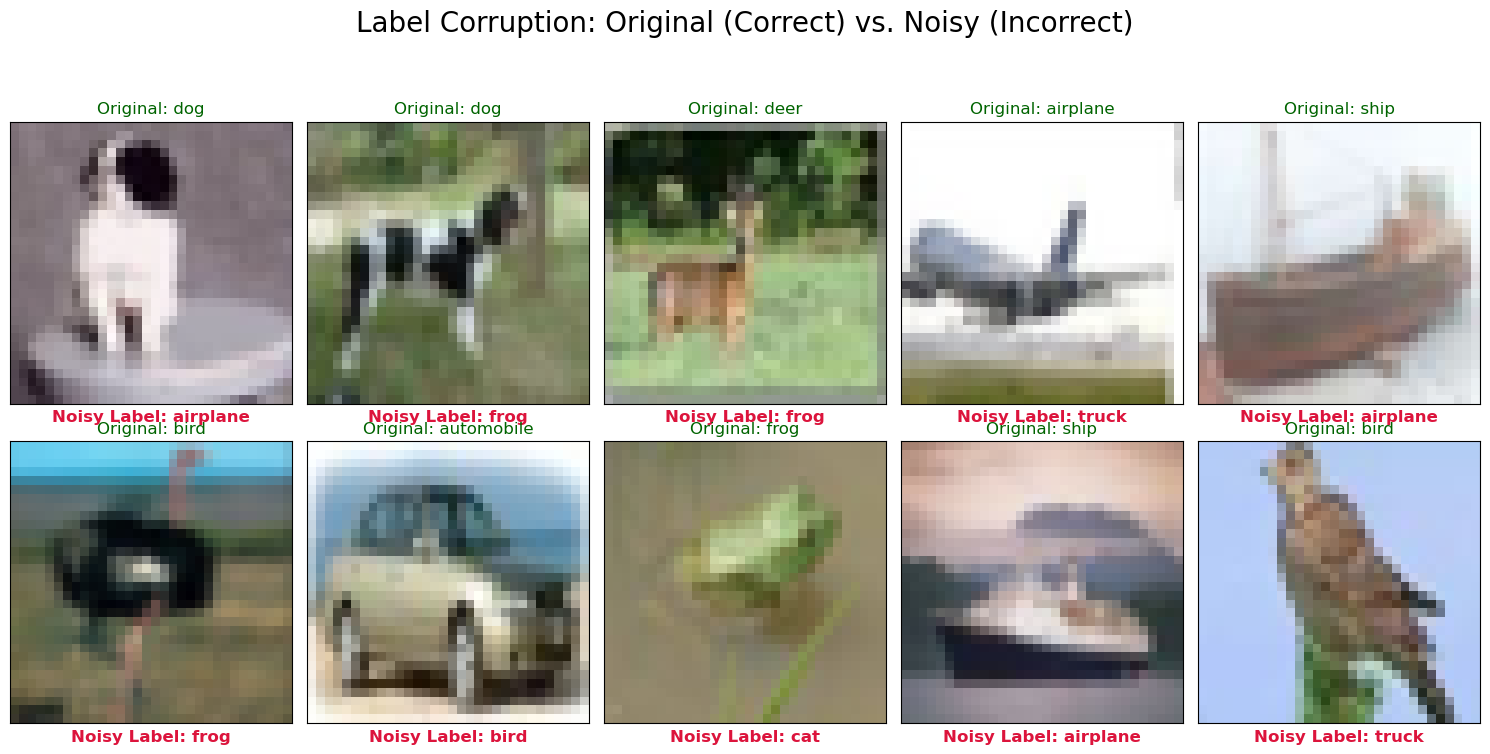

In [29]:
import matplotlib.pyplot as plt
import numpy as np

print("\n--- Visualizing Label Noise (Improved Version) ---")

cifar_train_clean = datasets.CIFAR10(root='./data', train=True, download=False, transform=transform) # download=False as it's already there
original_labels = np.array(cifar_train_clean.targets)
noisy_labels = np.array(noisy_train_dataset.targets)
class_names = cifar_train_clean.classes

corrupted_indices = np.where(original_labels != noisy_labels)[0]

fig, axes = plt.subplots(2, 5, figsize=(15, 8)) # Increased height slightly for labels
fig.suptitle('Label Corruption: Original (Correct) vs. Noisy (Incorrect)', fontsize=20, y=0.98)
axes = axes.flatten()

for i, ax in enumerate(axes):
    idx = np.random.choice(corrupted_indices)
    image, _ = noisy_train_dataset[idx]
    original_label_name = class_names[original_labels[idx]]
    noisy_label_name = class_names[noisy_labels[idx]]
    image = image * 0.5 + 0.5
    image_to_show = np.transpose(image.numpy(), (1, 2, 0))
    ax.imshow(image_to_show, interpolation='nearest')
    title_str = f"Original: {original_label_name}"
    label_str = f"Noisy Label: {noisy_label_name}"
    
    ax.set_title(title_str, color="darkgreen", fontsize=12)
    ax.set_xlabel(label_str, color="crimson", fontsize=12, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle and xlabels
plt.show()

# Explorations

**Multi-Level Explorations (The Crucible)**

* **Beginner**: 

    After running the noisy training, what is the final validation accuracy? Now, create a new, clean CIFAR-10 `DataLoader` and run the exact same training process. What is the final accuracy on the clean data? This difference quantifies the damage caused by noisy labels.

* **Intermediate**: 

    The model is trying to fit the noisy labels, resulting in a high training loss. A common technique is to use a smaller learning rate when you suspect noisy labels. Rerun the crucible training with `LEARNING_RATE = 0.0001`. Does this improve the final validation accuracy? Why might a smaller step size help?

* **Advanced**: 

    Research a simple technique for handling label noise called "Co-teaching" or "Sample Selection." A basic version is: after a few "warm-up" epochs (e.g., 5), modify your training loop. In each batch, calculate the loss for each sample individually. Then, only perform the backward pass and optimizer step on the 70% of samples with the lowest loss. This intentionally ignores the samples the model finds most confusing, which are likely the ones with wrong labels.


# Dataset-Specific Explorations

**Replication**:
    
Take your "Clinical" train.py script and apply it to the original MNIST digits dataset. It should be a simple drop-in replacement for FashionMNIST. Log the final validation accuracy.

**Modification**:
    
Use the Breast Cancer dataset from Chunk 4. You will need to adapt the training loop. Since it's a binary problem, what loss function should you use? What metric should you track instead of multi-class accuracy? (Hint: Binary accuracy, or look up Precision/Recall).

**Creation**:
    
Build and run a complete training loop for the California Housing dataset (a regression problem). This is a great challenge. You will need to:

* Build a model that outputs 1 continuous value.
* Use nn.MSELoss as your loss function.
* Change the validation metric. "Accuracy" is meaningless for regression. Track the validation loss, or even better, the Mean Absolute Error (MAE).
